# 1. Setup

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# Set style for better plots
sns.set(style="whitegrid", palette="colorblind", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Scaling Laws
# 2.1 Data Preparation
Currently only placeholder data

In [4]:
scaling_data = {
    "model_size": ["XS", "S", "M", "L", "XS", "S", "M", "L"],
    "dataset_size": [10, 10, 10, 10, 25, 25, 25, 25],
    "val_loss": [3.2, 2.8, 2.5, 2.3, 3.1, 2.7, 2.4, 2.2],
    "train_loss": [3.1, 2.7, 2.4, 2.1, 3.0, 2.6, 2.3, 2.0],
    "flops": [1e12, 5e12, 2e13, 8e13, 1e12, 5e12, 2e13, 8e13]
}
df_scaling = pd.DataFrame(scaling_data)

##need to change above when i know where i get the data from....

# 2.2 Loss Grid Table

In [5]:
pivot_val_loss = df_scaling.pivot(index="model_size", columns="dataset_size", values="val_loss")
print("Validation Loss Grid:")
display(pivot_val_loss)

Validation Loss Grid:


dataset_size,10,25
model_size,,
L,2.3,2.2
M,2.5,2.4
S,2.8,2.7
XS,3.2,3.1


# 2.3 Scaling Plots

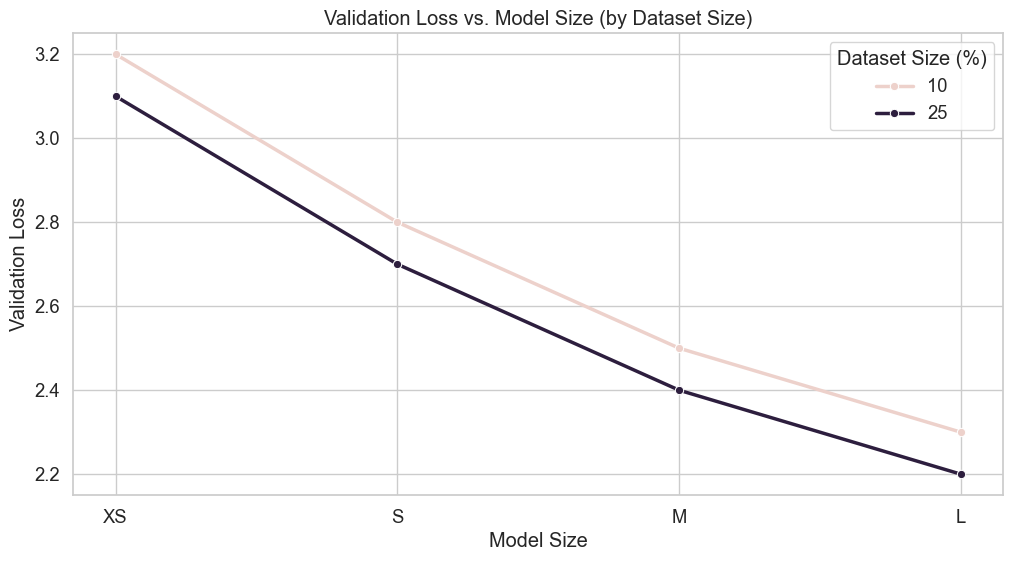

In [6]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_scaling, x="model_size", y="val_loss", hue="dataset_size", marker="o", linewidth=2.5)
plt.title("Validation Loss vs. Model Size (by Dataset Size)")
plt.ylabel("Validation Loss")
plt.xlabel("Model Size")
plt.grid(True)
plt.legend(title="Dataset Size (%)")
plt.show()



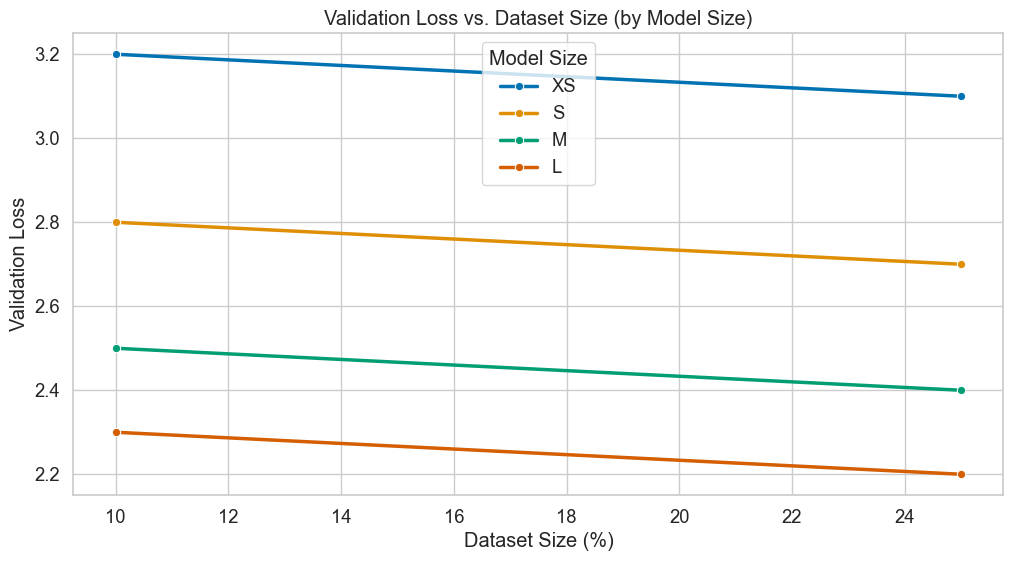

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_scaling, x="dataset_size", y="val_loss", hue="model_size", marker="o", linewidth=2.5)
plt.title("Validation Loss vs. Dataset Size (by Model Size)")
plt.ylabel("Validation Loss")
plt.xlabel("Dataset Size (%)")
plt.grid(True)
plt.legend(title="Model Size")
plt.show()



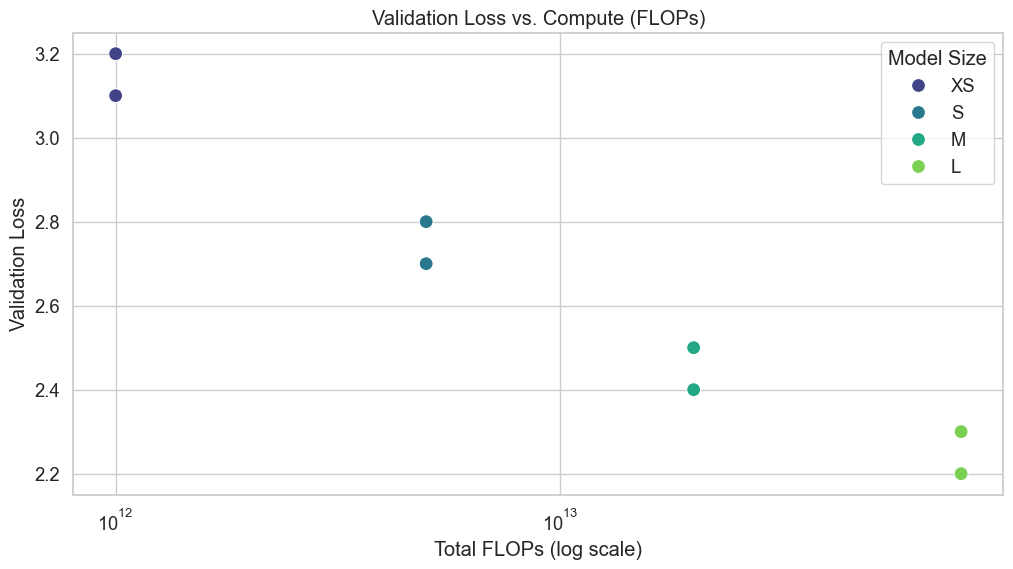

In [8]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_scaling, x="flops", y="val_loss", hue="model_size", s=100, palette="viridis")
plt.xscale('log')
plt.title("Validation Loss vs. Compute (FLOPs)")
plt.ylabel("Validation Loss")
plt.xlabel("Total FLOPs (log scale)")
plt.grid(True)
plt.legend(title="Model Size")
plt.show()



# 2.4 Compute-Optimal Frontier


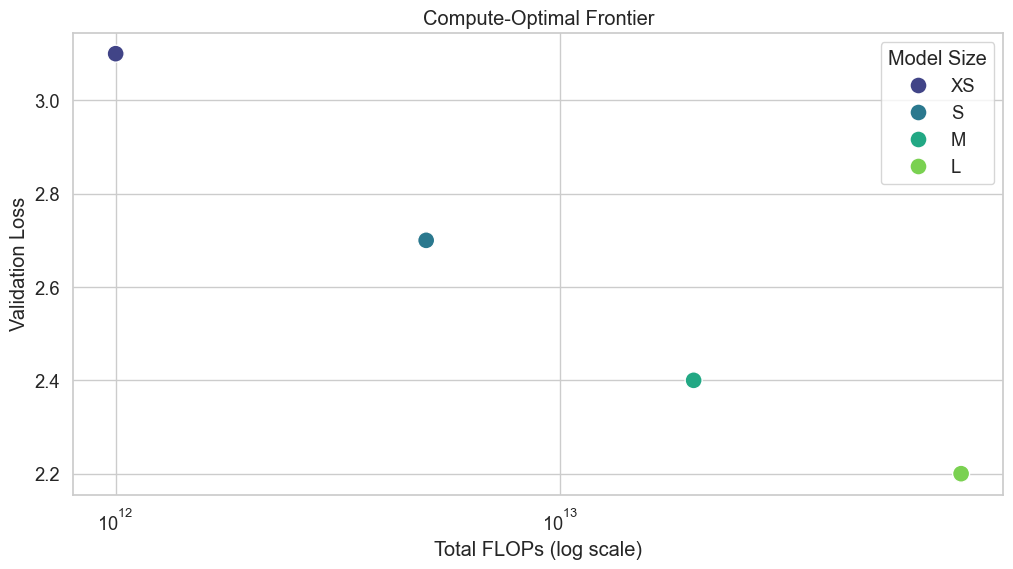

In [9]:
optimal = df_scaling.loc[df_scaling.groupby('flops')['val_loss'].idxmin()]
plt.figure(figsize=(12, 6))
sns.scatterplot(data=optimal, x="flops", y="val_loss", hue="model_size", s=150, palette="viridis")
plt.xscale('log')
plt.title("Compute-Optimal Frontier")
plt.ylabel("Validation Loss")
plt.xlabel("Total FLOPs (log scale)")
plt.grid(True)
plt.legend(title="Model Size")
plt.show()